In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# libraries load successfully

Meaningful questions about the dataset before analysis.

How many passengers survived?
How many passengers died?
What is the survival percentage?
Which gender survived more?
Which passenger class survived the most?
Which class paid the highest fare?
What is the average passenger age?
Did children survive more than adults?
Which embarkation port had the highest number of passengers?
Which features are related to survival?

In [ ]:
df = pd.read_csv("train.csv")

# The Titanic dataset was loaded into a DataFrame named df.



# Explore the data structure, including variables and data types.



In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
(df.isnull().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

Meaningful questions about the dataset before analysis.

How many passengers survived?
How many passengers died?
What is the survival percentage?
Which gender survived more?
Which passenger class survived the most?
Which class paid the highest fare?
What is the average passenger age?
Did children survive more than adults?
Which embarkation port had the highest number of passengers?
Which features are related to survival?


# Clean Data

apply below steps to clean dataset

# Fill missing Age

In [13]:
df['Age']=df['Age'].fillna(df['Age'].median())


# Missing values in the Age column were replaced with the median age because it is less affected by extreme values.

In [14]:
# afther apply median  the out is 

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Fill Embarked

In [15]:
# Before filling
print("Missing values before:", df["Embarked"].isnull().sum())

Missing values before: 2


In [18]:
# Fill missing values in Embarked using the mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [19]:
### After filling

print("Missing values after:", df["Embarked"].isnull().sum())

# The missing values in the Embarked column were replaced with the most frequently occurring embarkation port.

Missing values after: 0


# Remove Cabin

In [20]:
df.drop("Cabin",axis=1,inplace=True)

# Verify

In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Explanation:

Missing values were handled to improve data quality. The Cabin column was removed because it contained too many missing values.

# Identify trends, patterns and anomalies within the data ?

1. Identify Trends

# i. Survival by Gender

In [22]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

# ii. Survival by Passenger Class

In [23]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

# iii. Age Distribution

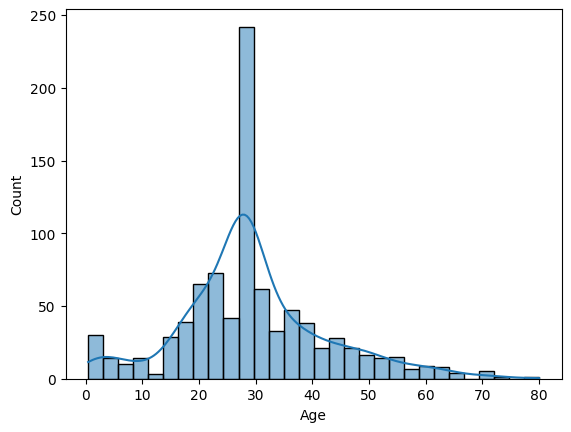

In [25]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.show()

2. Identify Patterns

# i. Gender and Survival

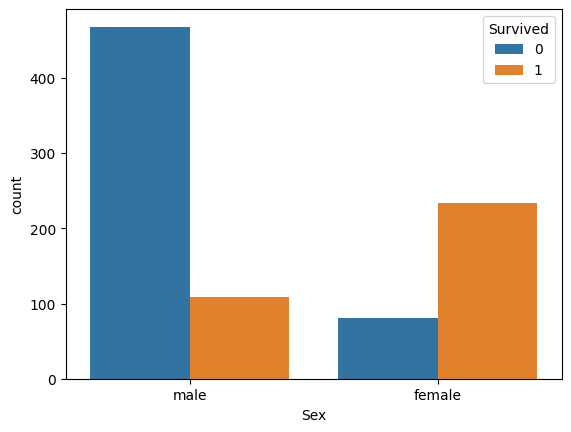

In [26]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()

# ii. Class and Fare

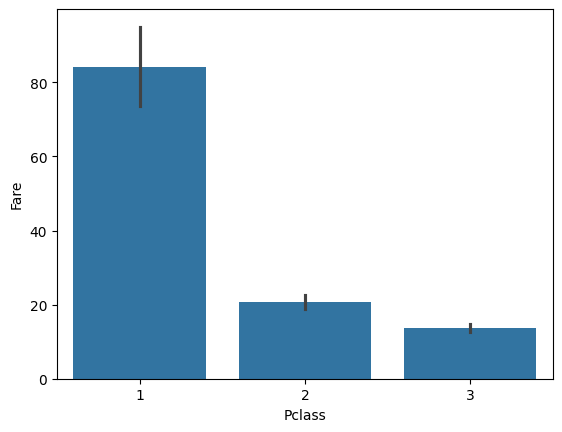

In [27]:
sns.barplot(x="Pclass", y="Fare", data=df)
plt.show()

# iii. Class and Survival

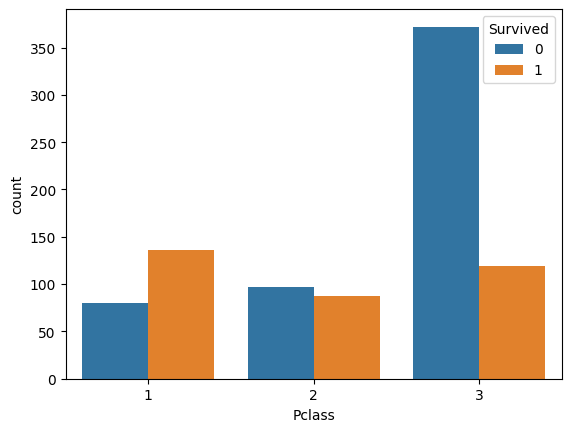

In [28]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.show()

# iv. Correlation Between Variables

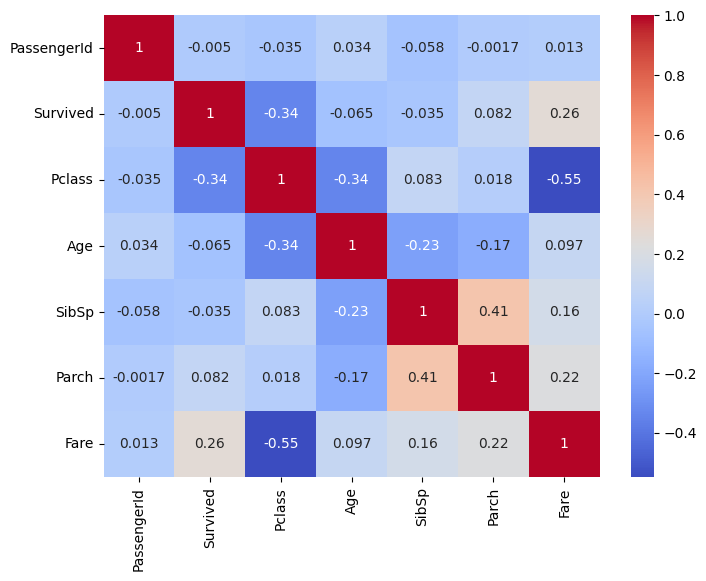

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

3. Identify Anomalies

Anomalies are unusual values that may affect analysis.

# i. Missing Values

In [30]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

 Test Hypotheses and Validate Assumptions

This step tests assumptions using statistical summaries and visualizations.

Hypothesis 1

Female passengers survived more than male passengers.

In [31]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

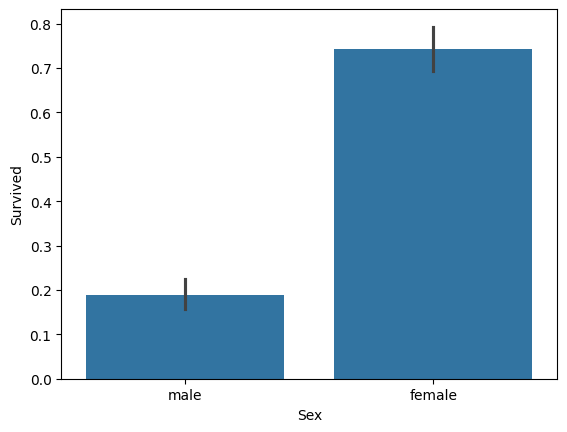

In [32]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.show()

### Observation

The results show that female passengers had a higher average survival rate than male passengers. Therefore, the hypothesis is supported.

Hypothesis 2

First Class passengers survived more than Third Class passengers.

In [33]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

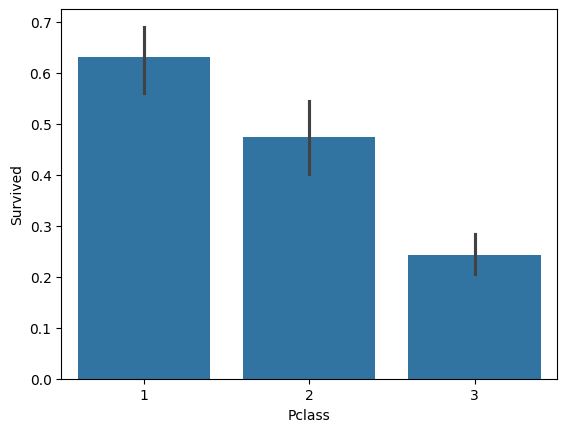

In [34]:
sns.barplot(x="Pclass", y="Survived", data=df)
plt.show()

### Observation

First Class passengers had the highest survival rate. The hypothesis is supported.

Hypothesis 3

Passengers paying higher fares had a greater chance of survival.

In [35]:
df.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

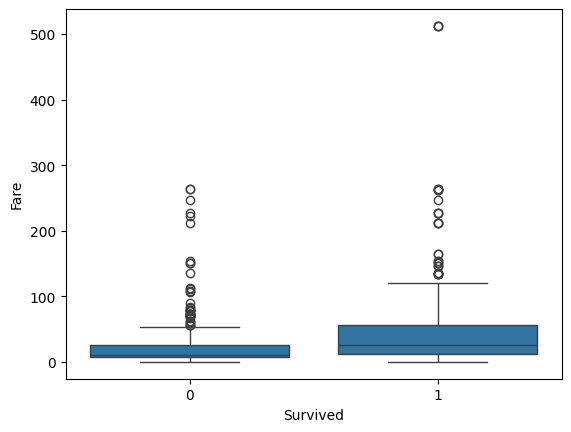

In [36]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.show()

### Observation

Passengers who survived generally paid higher fares than those who did not survive.

Detect Potential Data Issues

This step identifies data quality issues that should be addressed before further analysis or machine learning.

Issue 1: Missing Values

In [38]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Observation

Age and Embarked contained missing values, while Cabin had many missing values. These issues were handled during data cleaning.

Issue 2: Duplicate Records

In [39]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset.

Issue 3: Outliers

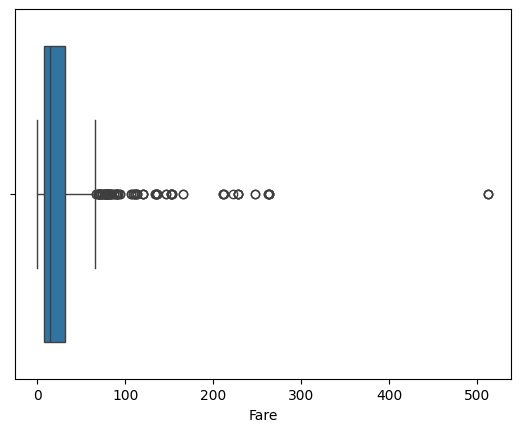

In [40]:
sns.boxplot(x=df["Fare"])
plt.show()

### Observation

Several outliers were detected in the Fare column.

Issue 4: Data Types

In [41]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object

### Observation

The dataset contains both numerical and categorical variables, which require different preprocessing techniques.

Issue 5: Class Imbalance

In [42]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### Observation

The number of passengers who did not survive is higher than the number who survived, indicating a class imbalance.